# Multivariate Time-Series Regression

This notebook orchestrates the validated Phase 0 through Phase 5 workflow for the UCI Appliances Energy Prediction coursework. Reusable computation, validation, plotting and artifact persistence are owned by the `course_work` package.

In [1]:
from IPython.display import Image, display

from course_work.contracts.coursework import load_coursework_contract, materialize_phase_0
from course_work.data.acquisition import materialize_phase_2
from course_work.data.schema import materialize_phase_3
from course_work.data.temporal import materialize_phase_4
from course_work.reporting.eda import materialize_phase_5
from course_work.utils.artifacts import get_project_root, read_json
from course_work.utils.environment import materialize_phase_1

PROJECT_ROOT = get_project_root()

## Phase 0 - Coursework Contract

Lock the prediction task, target, horizon, chronological protocol, model comparisons, metrics, research questions and leakage controls before any data-dependent work.

In [2]:
phase_0_contract = load_coursework_contract()
phase_0_signoff = materialize_phase_0(PROJECT_ROOT)
display(phase_0_contract["problem"])
display(phase_0_signoff)

{'task': 'multivariate_time_series_regression',
 'dataset': 'UCI Appliances Energy Prediction',
 'target': 'Appliances',
 'target_unit': 'Wh',
 'sampling_minutes': 10,
 'forecast_horizon_steps': 1,
 'forecast_horizon_minutes': 10,
 'sample_definition': 'X[t-L+1:t] -> Appliances[t+1]'}

{'artifact_version': 'COURSEWORK-CONTRACT-v1',
 'config_fingerprint': '4ec15ffd52092d8f3b9675a1e119afe6af1dab3b9da228d2bb6c4cba14f4b7c7',
 'created_at': '2026-08-14T18:39:02.965333+00:00',
 'dataset_revision': None,
 'discrepancies': [],
 'environment_id': None,
 'input_checksums': {'configs/base/coursework_contract.json': '09a3e13a1481c96a005670d0ef0cfe989410e42da78fec735b6d69b445b5d66f'},
 'input_paths': ['configs/base/coursework_contract.json'],
 'output_checksums': {'artifacts/contracts/coursework_contract.json': '4ec15ffd52092d8f3b9675a1e119afe6af1dab3b9da228d2bb6c4cba14f4b7c7',
  'artifacts/contracts/coursework_contract.sha256': '997ab4c28697f2fce2c7e880827319cc33b92cd1971030de1f38018460ac1404'},
 'output_paths': ['artifacts/contracts/coursework_contract.json',
  'artifacts/contracts/coursework_contract.sha256'],
 'phase_id': 0,
 'phase_version': 'PHASE-0-v1',
 'status': 'PASS',
 'tests': ['contract_schema',
  'option_registry_completeness',
  'chronological_split_sum',
  'foreca

## Phase 1 - Environment

Verify the interpreter, notebook kernel, dependency versions, compute device, deterministic configuration and training smoke test.

In [3]:
phase_1_signoff = materialize_phase_1(PROJECT_ROOT)
phase_1_environment = read_json(PROJECT_ROOT / "artifacts/environment/environment_report.json")
display(phase_1_environment)
display(phase_1_signoff)

{'architecture': 'arm64',
 'compute_environment_variables': {},
 'cpu_count': 10,
 'created_at': '2026-08-14T18:43:43.949250+00:00',
 'cuda_available': False,
 'cuda_device_count': 0,
 'cuda_device_name': None,
 'cuda_version': None,
 'default_dtype': 'torch.float32',
 'deterministic_mode': 'D0',
 'development_seed': 42,
 'environment_id': 'ENV-v1',
 'kernel': {'kernel_executable': '/Library/Frameworks/Python.framework/Versions/3.10/bin/python3.10',
  'kernel_name': 'python3',
  'kernel_spec_path': '/Users/voanhnhat-ticoder-coder/Documents/DEEP_LEARNING/TOTAL_LABPARACTICE_FOR_DEEP_LEARNING/venv/share/jupyter/kernels/python3/kernel.json',
  'matches_interpreter': True},
 'mps_available': False,
 'mps_built': True,
 'mps_device_name': None,
 'mps_fallback_enabled': False,
 'package_versions': {'ipykernel': '7.3.0',
  'jupyter': '1.1.1',
  'matplotlib': '3.10.9',
  'numpy': '2.2.6',
  'pandas': '2.3.3',
  'scikit_learn': '1.7.2',
  'torch': '2.13.0'},
 'pip_version': '26.2.1',
 'platform'

{'artifact_version': 'ENV-v1',
 'config_fingerprint': '4ec15ffd52092d8f3b9675a1e119afe6af1dab3b9da228d2bb6c4cba14f4b7c7',
 'created_at': '2026-08-14T18:43:43.950492+00:00',
 'dataset_revision': None,
 'discrepancies': [],
 'environment_id': 'ENV-v1',
 'input_checksums': {'artifacts/contracts/phase_0_signoff.json': '96b2e34737e43cac59d29d847b4f123f1e28a30ca372ac1f31a2823c8959d2c3'},
 'input_paths': ['artifacts/contracts/phase_0_signoff.json'],
 'output_checksums': {'artifacts/environment/environment_report.json': 'c0fbf498e86620e1ba52e909117e61b0a309fa7ec23fe30c89bed848cdce2524',
  'artifacts/environment/requirements_freeze.txt': '36b39b0eb4428aa446b55e89f975d43026b0d69f632b78369330b9c5bf905af5',
  'artifacts/environment/smoke_test_report.json': '03573a66b9ec7af94d86df2cd8c523fd2d20a25f0cb8ae5773bc6322eaea3b1a'},
 'output_paths': ['artifacts/environment/environment_report.json',
  'artifacts/environment/requirements_freeze.txt',
  'artifacts/environment/smoke_test_report.json'],
 'phase

## Phase 2 - Data Acquisition

Verify canonical UCI provenance, immutable raw bytes, archive membership, dataset metadata and acquisition sign-off without fetching data from the notebook.

In [4]:
phase_2_signoff = materialize_phase_2(PROJECT_ROOT)
phase_2_manifest = read_json(PROJECT_ROOT / "data/raw_data/dataset_manifest.json")
display(phase_2_manifest)
display(phase_2_signoff)

{'acquired_at_local': '2026-08-15T01:51:40.728062+07:00',
 'acquired_at_utc': '2026-08-14T18:51:40.728048+00:00',
 'archive_integrity_ok': True,
 'archive_paths_safe': True,
 'archive_sha256': '2fccf354445d886e7917620b0195db1f3e3e34d5a067a93b844694a4c561255a',
 'archive_size_bytes': 11979507,
 'characteristics': ['Multivariate', 'Time-Series'],
 'creator': 'Luis Candanedo',
 'csv_sha256': '2820bf712ad0275cb18b85a05250926100d8e65ebb9f4d2d016ca91ea152a25d',
 'csv_size_bytes': 11979363,
 'csv_smoke_test_ok': True,
 'dataset_name': 'Appliances Energy Prediction',
 'dataset_page': 'https://archive.ics.uci.edu/dataset/374/appliances+energy+prediction',
 'dataset_revision': 'DATA-v1',
 'doi': '10.24432/C5VC8G',
 'download_method': 'AQ0_direct_uci',
 'environment_id': 'ENV-v1',
 'expected_csv': 'energydata_complete.csv',
 'feature_type': 'Real',
 'license': 'CC BY 4.0',
 'license_url': 'https://creativecommons.org/licenses/by/4.0/',
 'local_archive_path': 'data/raw_data/source/appliances_energ

{'artifact_version': 'DATA-v1',
 'config_fingerprint': '4ec15ffd52092d8f3b9675a1e119afe6af1dab3b9da228d2bb6c4cba14f4b7c7',
 'created_at': '2026-08-14T18:51:40.735383+00:00',
 'dataset_revision': 'DATA-v1',
 'discrepancies': [],
 'environment_id': 'ENV-v1',
 'input_checksums': {'artifacts/environment/phase_1_signoff.json': 'd5ebc30357c3b2bc679339ae193c47023a1bfe124bfb6c498770c18129d19627',
  'data/raw_data/energydata_complete.csv': '2820bf712ad0275cb18b85a05250926100d8e65ebb9f4d2d016ca91ea152a25d'},
 'input_paths': ['artifacts/environment/phase_1_signoff.json',
  'data/raw_data/energydata_complete.csv'],
 'output_checksums': {'artifacts/acquisition/acquisition_log.json': '00345f790e24540a146f0641cb7aeeba66739b954b141994626ea278681f38b4',
  'data/raw_data/README_SOURCE.md': '88450f0a709399e975050d4db5e0f70199e12efe79b84e0d0a8812ce9d264ab4',
  'data/raw_data/checksums.sha256': '3dd998be0f1b9e9893042e6833907e2d309016f421325dfb6f93c0716c0d9daa',
  'data/raw_data/dataset_manifest.json': 'f5c

## Phase 3 - Schema Audit

Audit shape, column order, types, missingness, finite values, timestamp parseability and documented differences between UCI metadata and the canonical raw file.

In [5]:
phase_3_signoff = materialize_phase_3(PROJECT_ROOT)
phase_3_manifest = read_json(PROJECT_ROOT / "artifacts/schema/schema_manifest.json")
display(phase_3_manifest)
display(phase_3_signoff)

{'all_null_columns': [],
 'audit_status': 'PASS_WITH_WARNING',
 'column_count': 29,
 'column_order_matches_expected': True,
 'constant_columns': [],
 'created_at': '2026-08-14T18:55:27.187289+00:00',
 'dataframe_fingerprint_after': '0b6301822d80775d62155682685c2bba62b420ecc62efcbe4a60865c96bc1066',
 'dataframe_fingerprint_before': '0b6301822d80775d62155682685c2bba62b420ecc62efcbe4a60865c96bc1066',
 'dataset_revision': 'DATA-v1',
 'dtype_mapping': {'Appliances': 'int64',
  'Press_mm_hg': 'float64',
  'RH_1': 'float64',
  'RH_2': 'float64',
  'RH_3': 'float64',
  'RH_4': 'float64',
  'RH_5': 'float64',
  'RH_6': 'float64',
  'RH_7': 'float64',
  'RH_8': 'float64',
  'RH_9': 'float64',
  'RH_out': 'float64',
  'T1': 'float64',
  'T2': 'float64',
  'T3': 'float64',
  'T4': 'float64',
  'T5': 'float64',
  'T6': 'float64',
  'T7': 'float64',
  'T8': 'float64',
  'T9': 'float64',
  'T_out': 'float64',
  'Tdewpoint': 'float64',
  'Visibility': 'float64',
  'Windspeed': 'float64',
  'date': 'ob

{'artifact_version': 'SCHEMA-v1',
 'config_fingerprint': '4ec15ffd52092d8f3b9675a1e119afe6af1dab3b9da228d2bb6c4cba14f4b7c7',
 'created_at': '2026-08-14T18:55:27.188865+00:00',
 'dataset_revision': 'DATA-v1',
 'discrepancies': ['SD-001'],
 'environment_id': 'ENV-v1',
 'input_checksums': {'artifacts/acquisition/phase_2_signoff.json': 'b59e8fec60ed018941e741bb6d162d38f8942af9d13de7833a1139855f6b3b46',
  'data/raw_data/energydata_complete.csv': '2820bf712ad0275cb18b85a05250926100d8e65ebb9f4d2d016ca91ea152a25d'},
 'input_paths': ['artifacts/acquisition/phase_2_signoff.json',
  'data/raw_data/energydata_complete.csv'],
 'output_checksums': {'artifacts/schema/schema_comparison.csv': '093a767b0967d2a003f31229dfcb3ce62890801c22a0c0bd5faa1000b0f2c548',
  'artifacts/schema/schema_discrepancies.json': '80f7f886a57c11be48df34be8003b2a0388d2ca5fd222a6b372f13003676bc35',
  'artifacts/schema/schema_fingerprint.txt': '7e5022d05814329704c15c47511c11439bda5b47ed404c1890b4d19f3ad13f02',
  'artifacts/schem

## Phase 4 - Temporal Integrity Audit

Verify strict timestamp parsing, ordering, duplicates, ten-minute cadence, missing timestamps, continuity segments and window-safety rules.

In [6]:
phase_4_signoff = materialize_phase_4(PROJECT_ROOT)
phase_4_manifest = read_json(PROJECT_ROOT / "artifacts/temporal/temporal_manifest.json")
display(phase_4_manifest)
display(phase_4_signoff)

{'audit_status': 'PASS',
 'conflicting_duplicate_group_count': 0,
 'continuity_ratio': 1.0,
 'continuity_segment_count': 1,
 'coverage_completeness_ratio': 1.0,
 'created_at': '2026-08-14T18:58:48.492501+00:00',
 'dataframe_fingerprint_after': '0b6301822d80775d62155682685c2bba62b420ecc62efcbe4a60865c96bc1066',
 'dataframe_fingerprint_before': '0b6301822d80775d62155682685c2bba62b420ecc62efcbe4a60865c96bc1066',
 'dataset_revision': 'DATA-v1',
 'duplicate_timestamp_count': 0,
 'duplicate_timestamp_group_count': 0,
 'elapsed_duration_minutes': 197340.0,
 'environment_id': 'ENV-v1',
 'expected_delta_count': 19734,
 'expected_grid_count': 19735,
 'expected_interval_minutes': 10,
 'gap_count': 0,
 'largest_gap_minutes': None,
 'max_timestamp': '2016-05-27 18:00:00',
 'min_timestamp': '2016-01-11 17:00:00',
 'missing_timestamp_count': 0,
 'negative_delta_count': 0,
 'off_grid_gap_count': 0,
 'off_grid_timestamp_count': 0,
 'parse_failure_count': 0,
 'parse_success_rate': 1.0,
 'parsed_timestam

{'artifact_version': 'TEMPORAL-v1',
 'config_fingerprint': '4ec15ffd52092d8f3b9675a1e119afe6af1dab3b9da228d2bb6c4cba14f4b7c7',
 'created_at': '2026-08-14T18:58:48.494320+00:00',
 'dataset_revision': 'DATA-v1',
 'discrepancies': [],
 'environment_id': 'ENV-v1',
 'input_checksums': {'artifacts/schema/phase_3_signoff.json': '3ce509eadab369b8b711f73038a9c3790d6b32e38bbdefd251633d6f508717f1',
  'data/raw_data/energydata_complete.csv': '2820bf712ad0275cb18b85a05250926100d8e65ebb9f4d2d016ca91ea152a25d'},
 'input_paths': ['artifacts/schema/phase_3_signoff.json',
  'data/raw_data/energydata_complete.csv'],
 'output_checksums': {'artifacts/temporal/continuity_segments.csv': '1f93fe3b96a34ab007482d554744140a5f59e9189b2ad384b72496cec5501b8b',
  'artifacts/temporal/daily_observation_counts.csv': 'b4d02d4371424379e35ffbf81de16f41ec1a7f87beb38dd19fad03e412d5db91',
  'artifacts/temporal/duplicate_timestamps.csv': '9b1883b806ef5eb6ed6fb4b87c6d4adf39cfb63d8d84ff5e31a01753cb0f056d',
  'artifacts/temporal

## Phase 5 - Exploratory Data Analysis

Materialize reproducible descriptive tables and canonical figures while preserving every raw row, deferring split-dependent analysis and recording all decision-sensitive observations as untested hypotheses.

In [7]:
phase_5_signoff = materialize_phase_5(PROJECT_ROOT)
phase_5_manifest = read_json(PROJECT_ROOT / "artifacts/eda/eda_manifest.json")
display(phase_5_manifest)
display(phase_5_signoff)

{'anomalies_count': 3,
 'correlation_threshold': {'absolute_pearson': 0.8,
  'purpose': 'descriptive_flag_not_feature_removal'},
 'created_at': '2026-08-14T19:06:31.674105+00:00',
 'dataset_revision': 'DATA-v1',
 'decision_sensitive_policy': 'hypotheses_require_future_train_validation_confirmation',
 'eda_version': 'EDA-v1',
 'environment_id': 'ENV-v1',
 'figures_generated': ['artifacts/eda/figures/EDA_01_target_histogram.png',
  'artifacts/eda/figures/EDA_02_target_ecdf.png',
  'artifacts/eda/figures/EDA_03_target_boxplot.png',
  'artifacts/eda/figures/EDA_04_target_timeline.png',
  'artifacts/eda/figures/EDA_05_energy_spikes.png',
  'artifacts/eda/figures/EDA_06_hourly_profile.png',
  'artifacts/eda/figures/EDA_07_weekday_profile.png',
  'artifacts/eda/figures/EDA_08_weekday_weekend.png',
  'artifacts/eda/figures/EDA_09_hour_weekday_heatmap.png',
  'artifacts/eda/figures/EDA_10_temperature_distributions.png',
  'artifacts/eda/figures/EDA_11_humidity_distributions.png',
  'artifacts/e

{'artifact_version': 'EDA-v1',
 'config_fingerprint': '4ec15ffd52092d8f3b9675a1e119afe6af1dab3b9da228d2bb6c4cba14f4b7c7',
 'created_at': '2026-08-14T19:06:31.677916+00:00',
 'dataset_revision': 'DATA-v1',
 'discrepancies': [],
 'environment_id': 'ENV-v1',
 'input_checksums': {'artifacts/acquisition/phase_2_signoff.json': 'b59e8fec60ed018941e741bb6d162d38f8942af9d13de7833a1139855f6b3b46',
  'artifacts/schema/phase_3_signoff.json': '3ce509eadab369b8b711f73038a9c3790d6b32e38bbdefd251633d6f508717f1',
  'artifacts/temporal/phase_4_signoff.json': 'e60f9ac7a638a8b29c46afd272757f545f40e2d3923472a3fda0831fb75e3627',
  'data/raw_data/energydata_complete.csv': '2820bf712ad0275cb18b85a05250926100d8e65ebb9f4d2d016ca91ea152a25d'},
 'input_paths': ['artifacts/acquisition/phase_2_signoff.json',
  'artifacts/schema/phase_3_signoff.json',
  'artifacts/temporal/phase_4_signoff.json',
  'data/raw_data/energydata_complete.csv'],
 'output_checksums': {'artifacts/eda/eda_anomalies.json': '1ceb52fa9f5f25cfdce

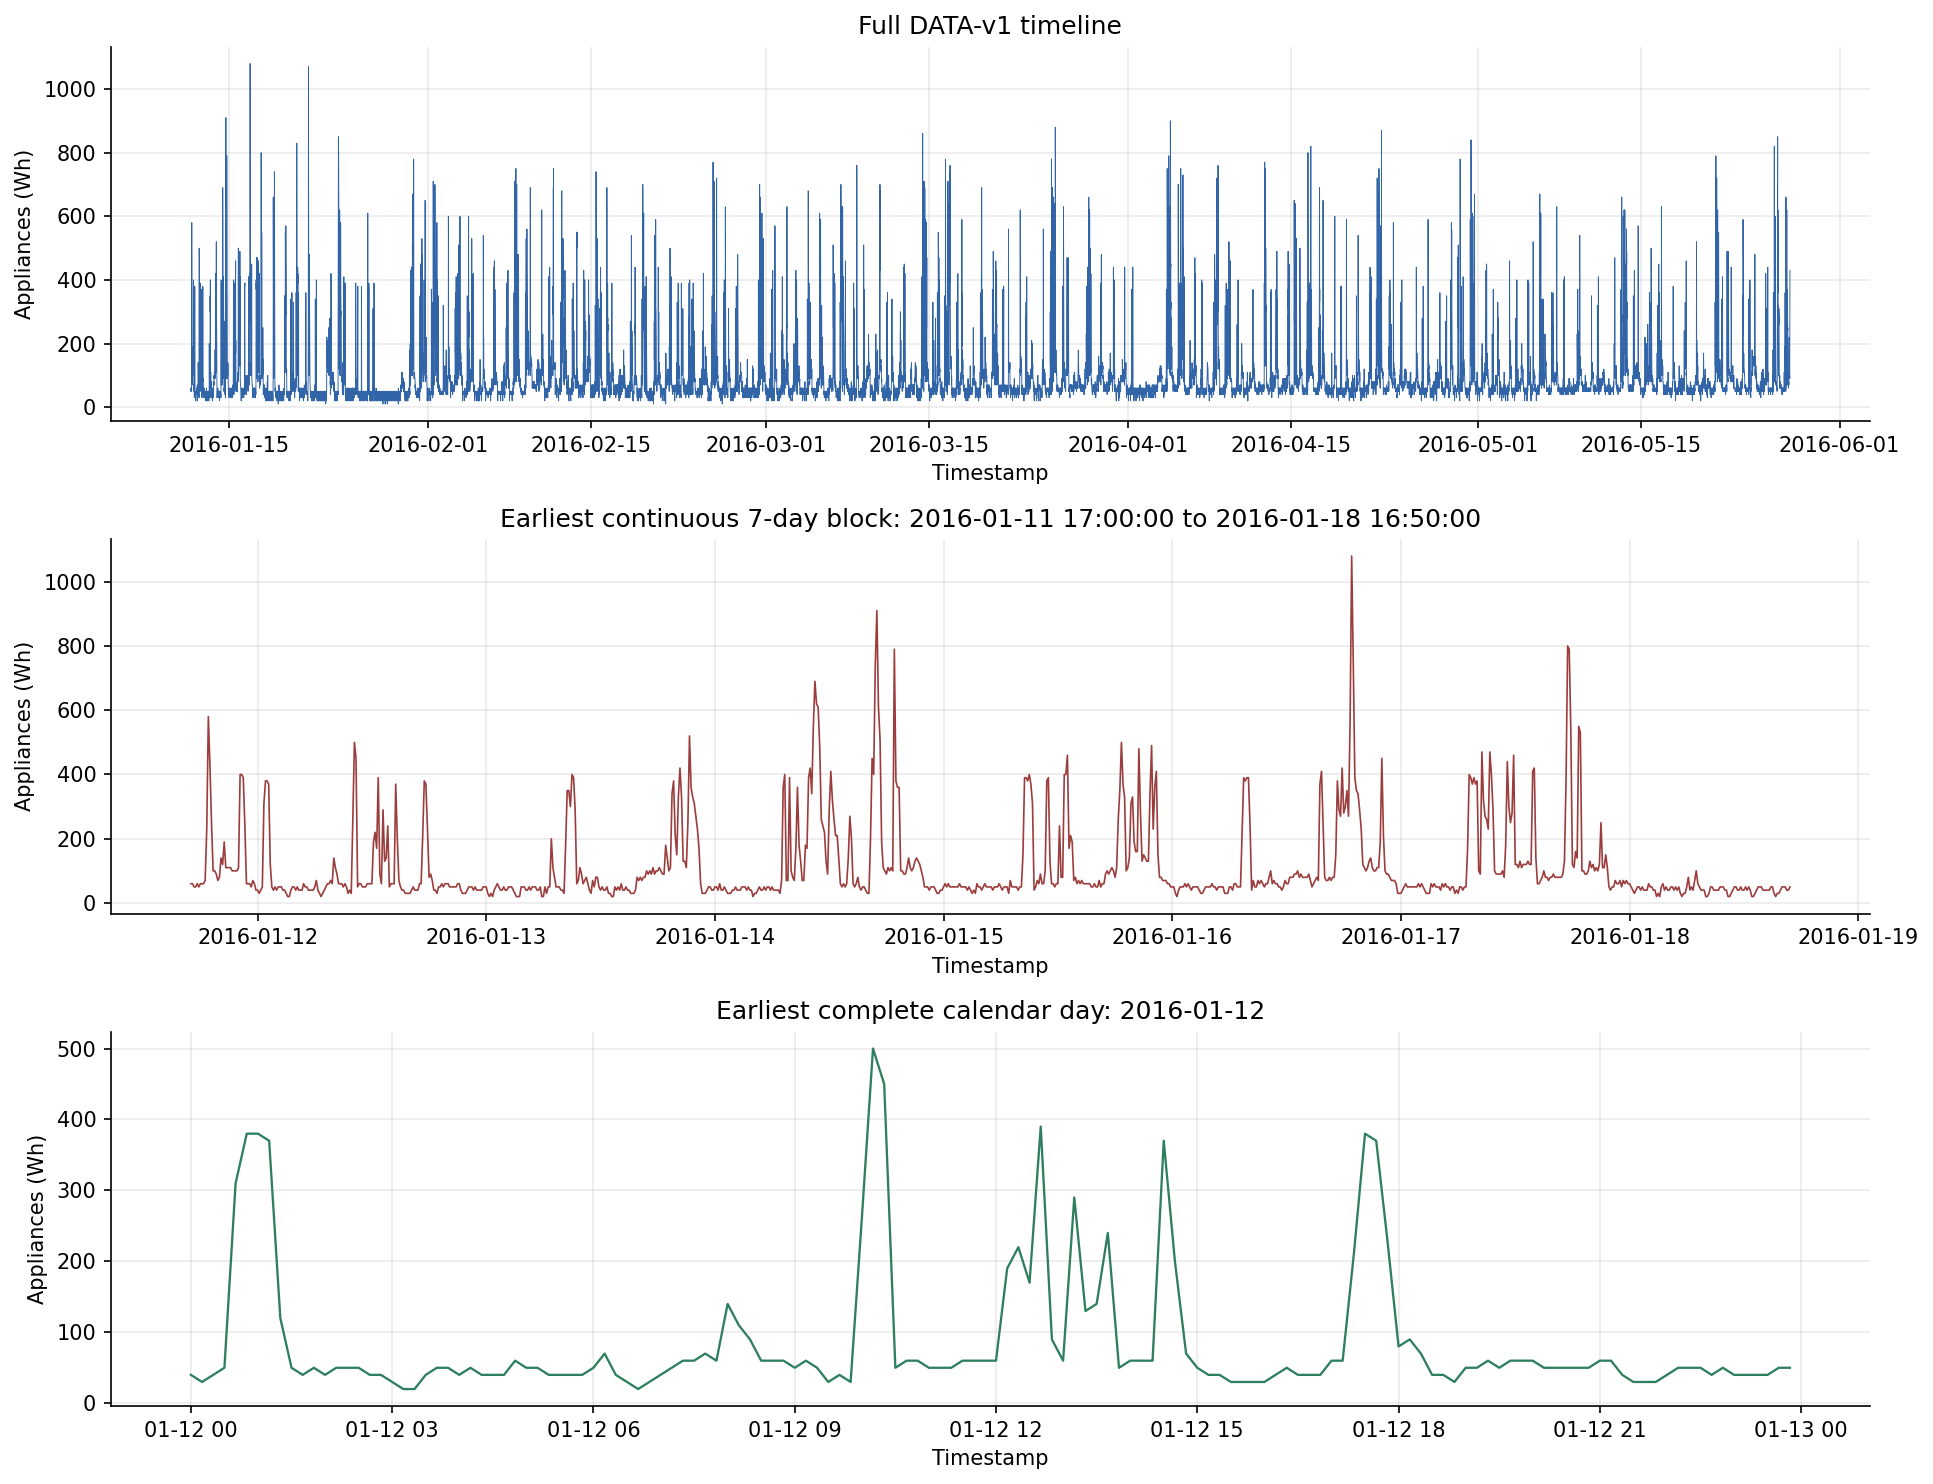

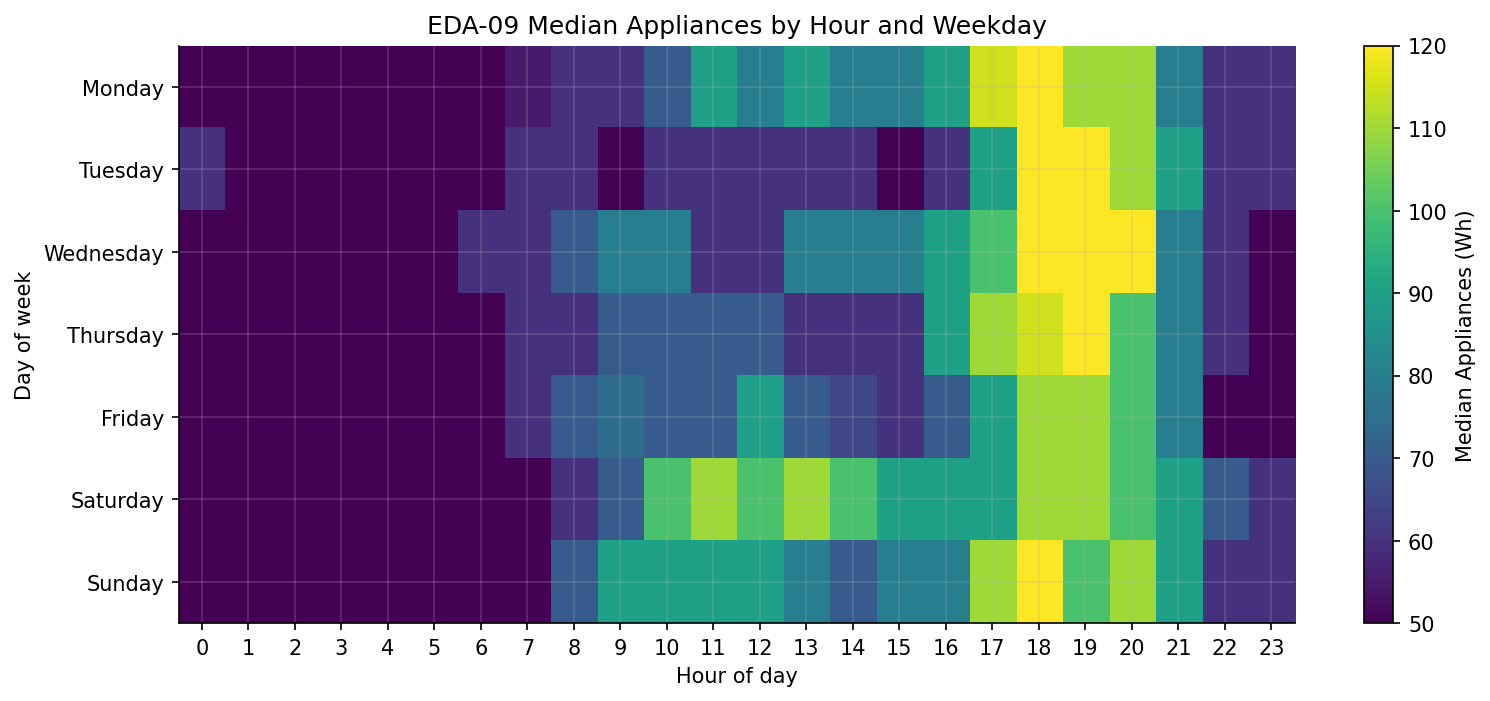

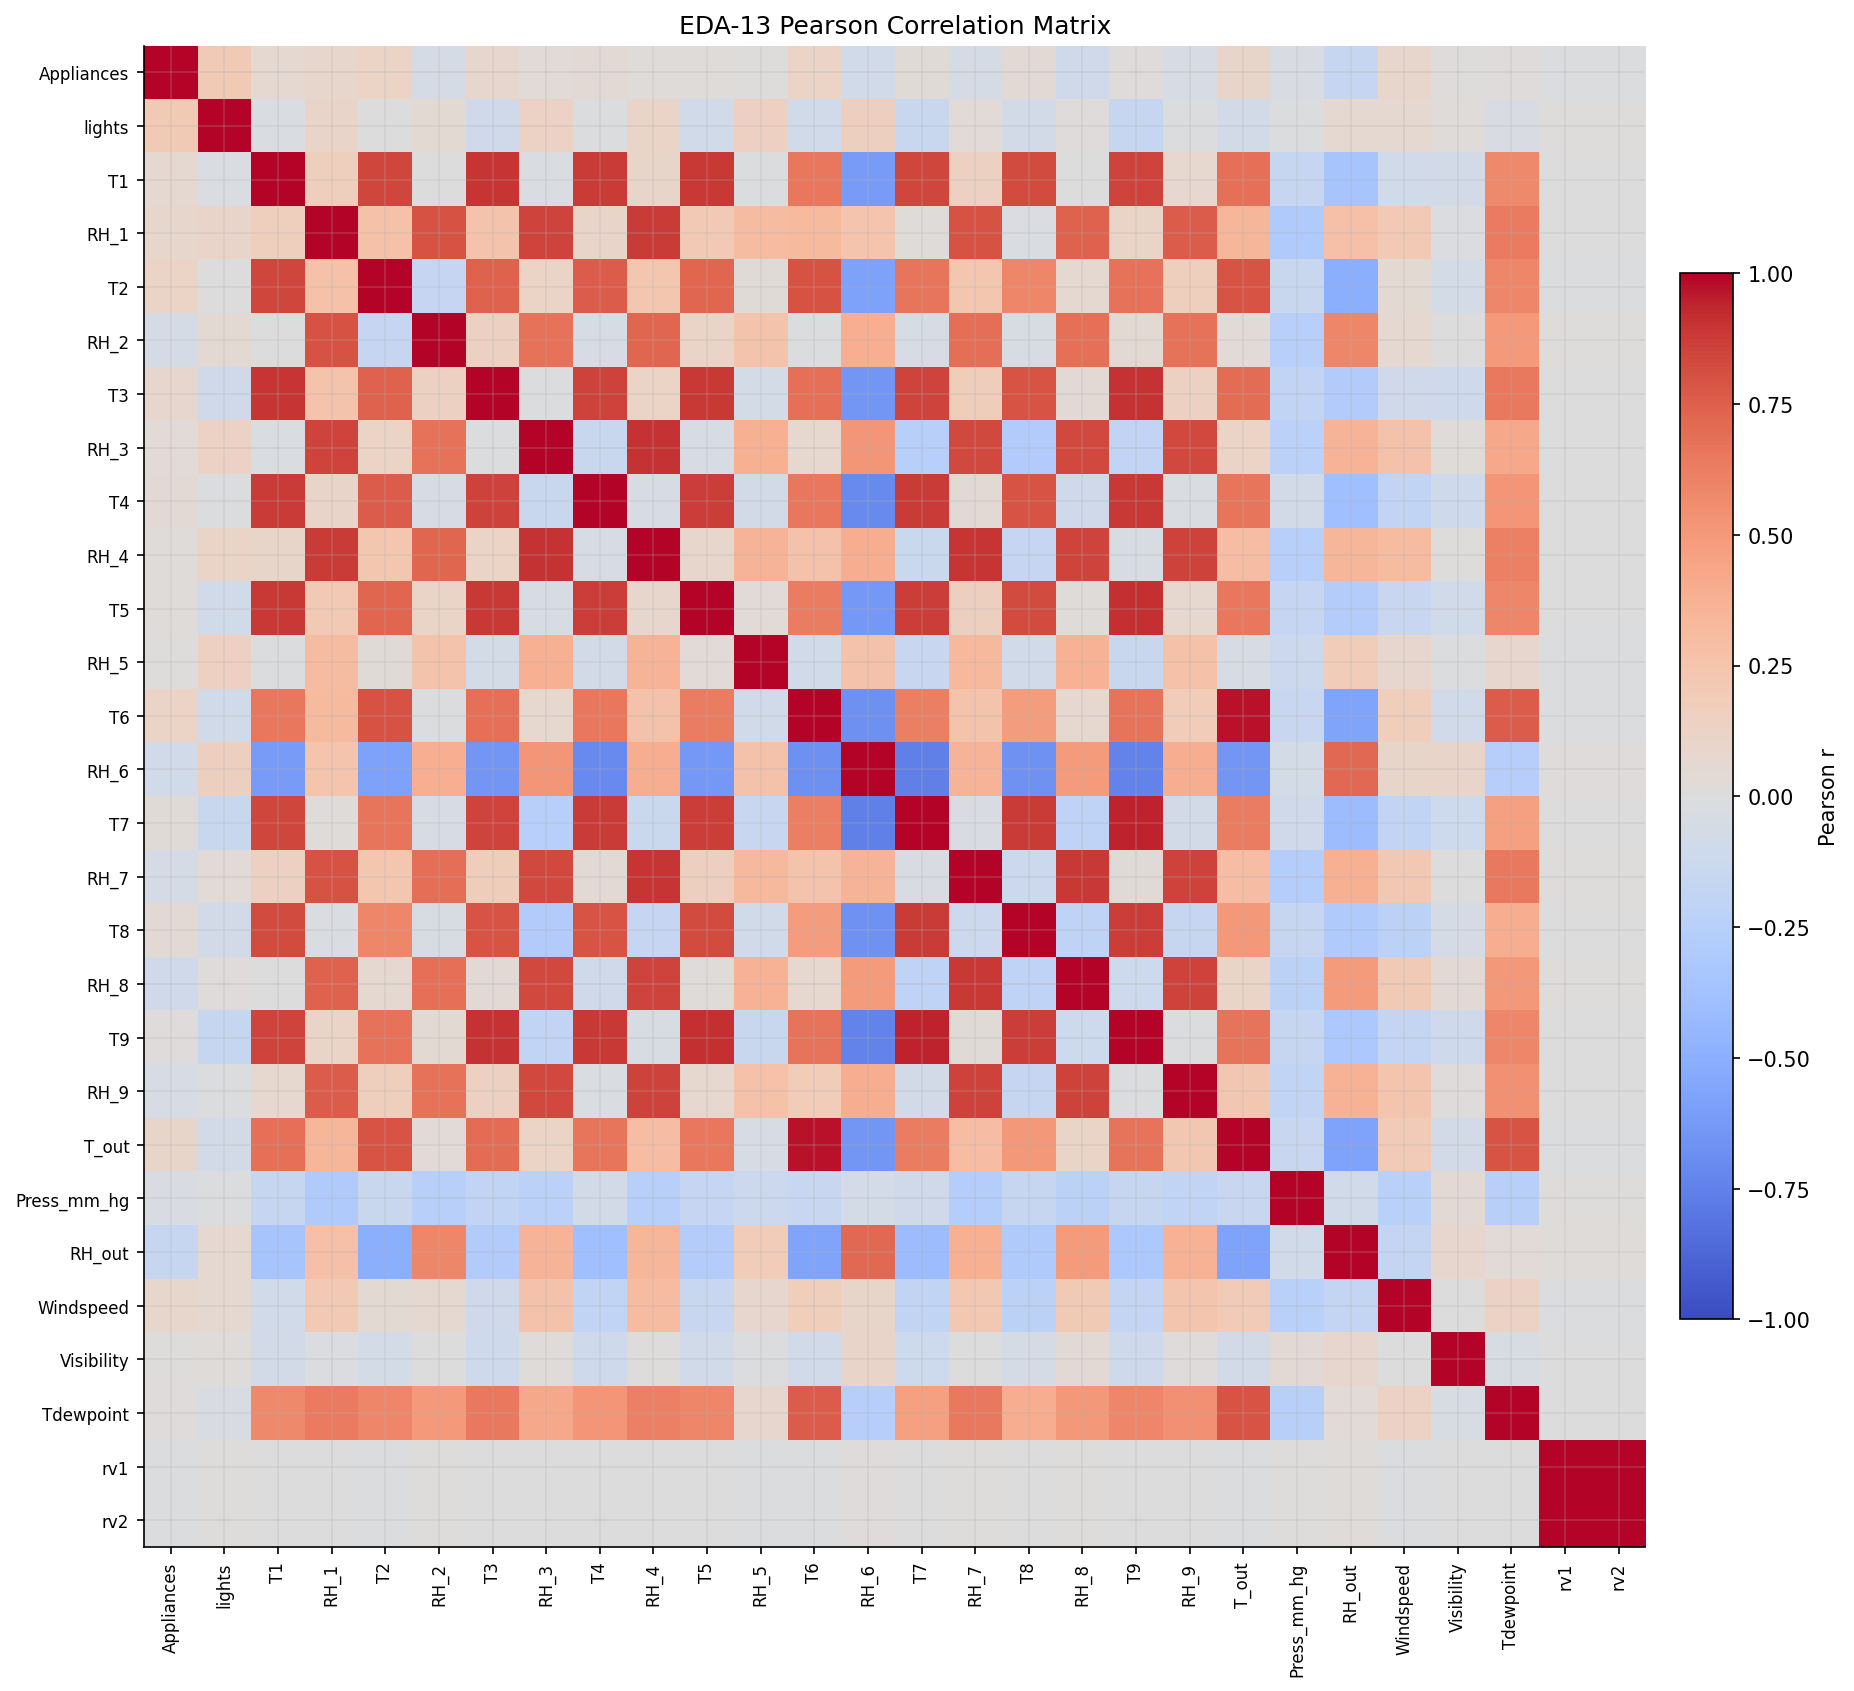

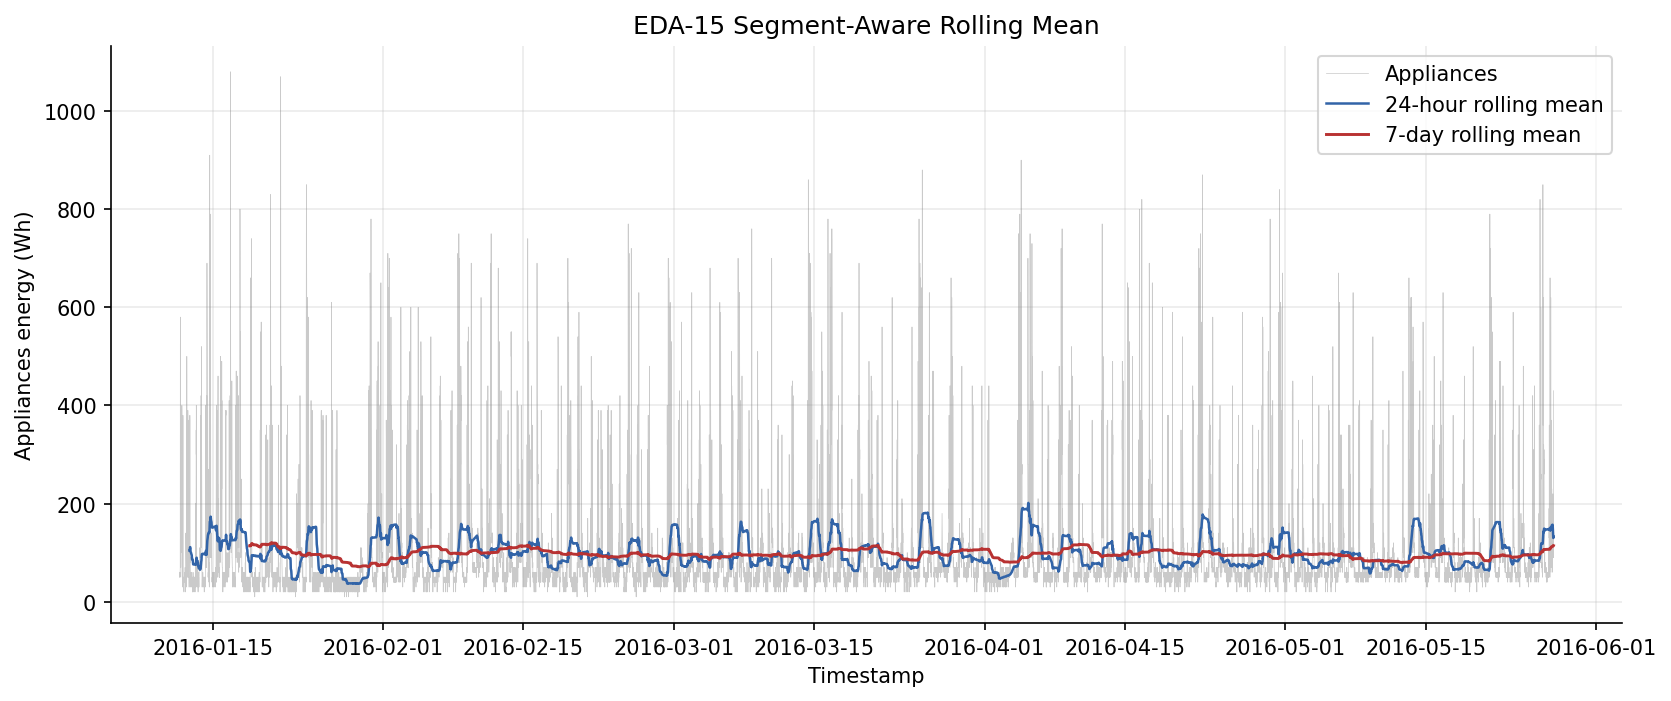

In [8]:
display(Image(filename=PROJECT_ROOT / "artifacts/eda/figures/EDA_04_target_timeline.png"))
display(Image(filename=PROJECT_ROOT / "artifacts/eda/figures/EDA_09_hour_weekday_heatmap.png"))
display(Image(filename=PROJECT_ROOT / "artifacts/eda/figures/EDA_13_correlation_heatmap.png"))
display(Image(filename=PROJECT_ROOT / "artifacts/eda/figures/EDA_15_rolling_mean.png"))

## Phase 0-5 Boundary

The validated workflow stops before feature engineering, chronological splitting, scaling, window construction, model implementation and training. Phase 6 and later work must consume the signed Phase 0-5 artifacts through their assigned source modules.